In [22]:
import pandas as pd
import numpy as np

file_path = 'players_data-2025_2026.csv' 
df = pd.read_csv(file_path, encoding='ISO-8859-1')

print(f"Dataset Loaded: {df.shape[0]} players, {df.shape[1]} features")
df.head()

Dataset Loaded: 2683 players, 102 features


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,27,21,...,1,0,0,14,37,5,30,13,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,16,3,...,0,0,0,4,3,1,25,2,1,0
3,4,Himad Abdelli,dz ALG,"FW,MF",Marseille,fr Ligue 1,26.0,1999.0,4,0,...,1,0,0,3,0,0,1,0,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0


In [23]:
# 1. Filter for players with at least 90 minutes played
df = df[df['Min'] >= 90].copy()


In [24]:
print(df.columns.tolist())


['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_s

In [25]:
# Calculate xG for each player we have data for using the formula: xG = Sh * (G/Sh)
df["xG"] = df["Sh"] * df["G/Sh"]

In [26]:
# 2. Select your Target (Expected Goals) and relevant Features
# Droping non-predictive metadata like Player names or Rank
features = df.drop(columns=['Player', 'Nation', 'Squad', 'Comp', 'Age', 'Born', 'Rk', ])



In [27]:
# Select only numeric data first
df_numeric = df.select_dtypes(include=[np.number]).copy()

# Fill ALL NaNs at once
df_numeric = df_numeric.fillna(0) 

# Ensure the target doesn't have NaNs
df_numeric = df_numeric.dropna(subset=['xG'])

X = df_numeric.drop(columns=['xG'])
y = df_numeric['xG']

In [28]:
target = "xG"

# Reuse the numeric feature matrix built above so restart-and-run works cleanly.
X = df_numeric.drop(columns=[target])
y = df_numeric[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2333, 81)
Target shape: (2333,)


In [29]:
print(features.columns.tolist())

['Pos', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_stats_playing_time', 'Starts_stats_playing_time', 'Mn/Start

In [30]:
# 5. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1866, 81)
Testing samples: (467, 81)


In [31]:
#feature scaling
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:

class LinearRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        
        for i in range(self.iterations):
            # Hypothesis: y_pred = (X * weights) + bias
            y_prediction = np.dot(X, self.weights) + self.bias
            
            # Calculate gradients (Vectorized)
            dw = (1 / m) * np.dot(X.T, (y_prediction - y))
            db = (1 / m) * np.sum(y_prediction - y)
            
            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # Track cost (MSE) to verify learning
            cost = (1 / (2 * m)) * np.sum((y_prediction - y) ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    
# --- 3. TRAINING & EVALUATION ---
model = LinearRegression(learning_rate=0.01, iterations=1000)
model.fit(X_train_scaled, y_train)
model.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


In [33]:
y_pred = model.predict(X_test_scaled)

print("Predictions sample:")
print(y_pred[:10])

Predictions sample:
[-7.60323050e-02  2.52777348e-02  1.70311864e-02  1.03139445e-01
  1.08902366e+00  4.14106854e-02  1.02786236e+01 -1.46652002e-01
  6.40902807e-03  1.01222799e+00]


In [34]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"R-squared Score: {r2:.4f}")

Mean Absolute Error: 0.0532
R-squared Score: 0.9981


In [35]:
results = pd.DataFrame({
    "Actual xG": y_test.values,
    "Predicted xG": y_pred
})

results.head(10)

,Actual xG,Predicted xG
0,0.00,-0.076032
1,0.00,0.025278
2,0.00,0.017031
3,0.00,0.103139
4,0.99,1.089024
5,0.00,0.041411
6,9.88,10.278624
7,0.00,-0.146652
8,0.00,0.006409
9,1.00,1.012228


In [36]:
new_player = X_test.iloc[0:1]

predicted_xg = model.predict(scaler.transform(new_player))

print("Predicted xG:", predicted_xg)

Predicted xG: [-0.07603231]


In [37]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.weights
})

coefficients.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
10,G-PK,0.695651
7,Gls,0.564188
39,Gls_stats_shooting,0.564188
9,G+A,0.332270
41,SoT,0.157762
40,Sh,0.044536
15,G+A-PK,0.033085
46,G/SoT,0.023926
45,G/Sh,0.019015
63,onG,0.015401


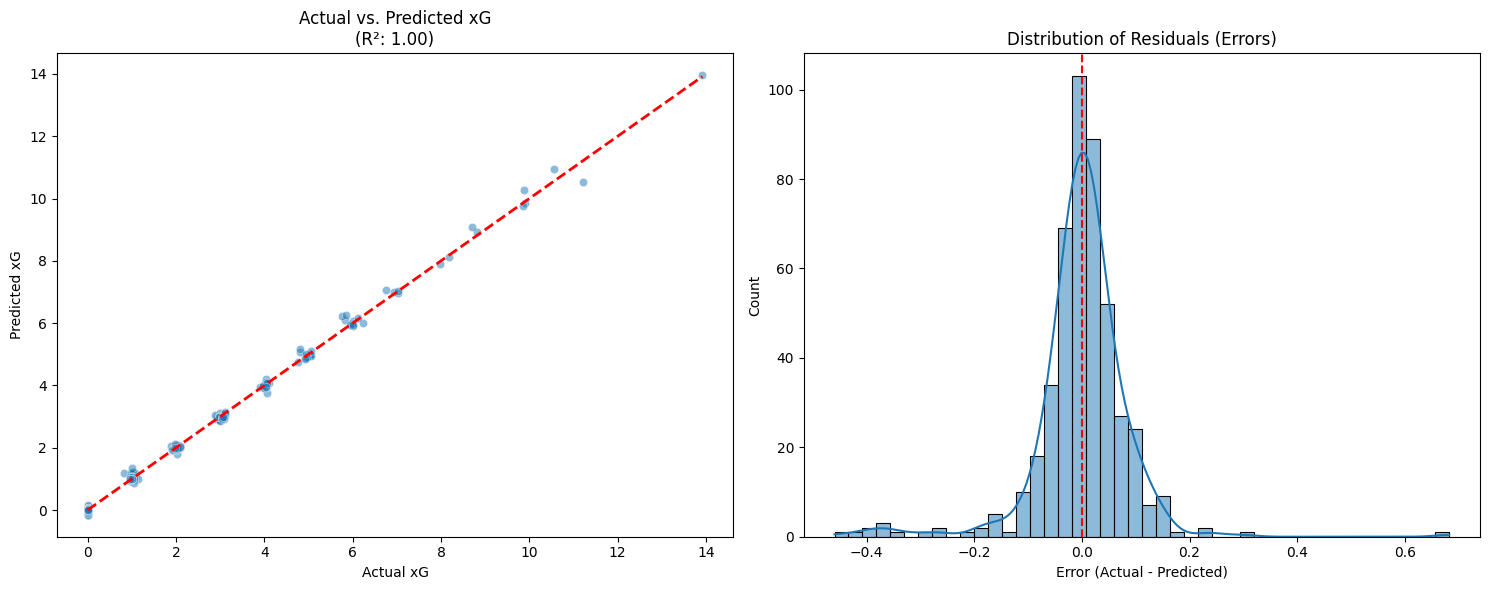

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=ax[0])
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_title(f'Actual vs. Predicted xG\n(R²: {r2:.2f})')
ax[0].set_xlabel('Actual xG')
ax[0].set_ylabel('Predicted xG')

# Plot 2: Residuals
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].axvline(0, color='r', linestyle='--')
ax[1].set_title('Distribution of Residuals (Errors)')
ax[1].set_xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

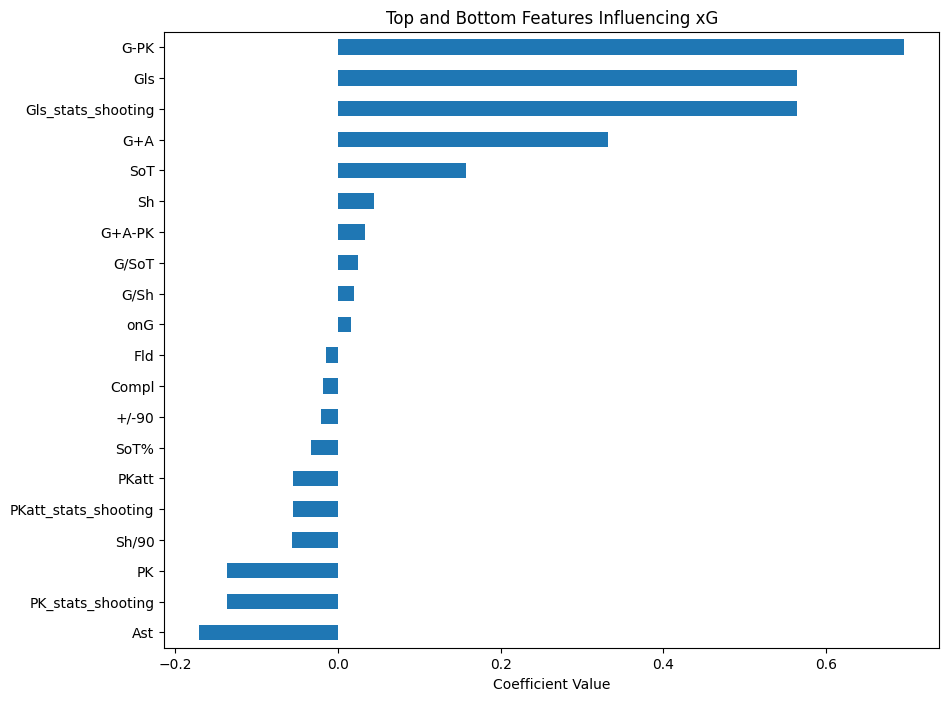

In [39]:
# Get coefficients from the linear model
importance = pd.Series(model.weights, index=X.columns).sort_values(ascending=False)

# Use concat instead of append
top_10 = importance.head(10)
bottom_10 = importance.tail(10)
to_plot = pd.concat([top_10, bottom_10])

# Plotting
plt.figure(figsize=(10, 8))
to_plot.plot(kind='barh')
plt.title('Top and Bottom Features Influencing xG')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis() # Optional: keeps the highest value at the top
plt.show()